In [57]:
import pandas as pd
from transformers import pipeline
from dotenv import load_dotenv
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from datetime import datetime
load_dotenv()

True

# Runing Finbert on Raw Minutes csv

In [18]:
df = pd.read_csv("../data/raw/minutes_text.csv")

finbert = pipeline(
    "text-classification",
    model="ProsusAI/finbert",
    tokenizer="ProsusAI/finbert",
    top_k=None
)

def score_full_document(text):
    chunks = [text[i:i+400] for i in range(0, len(text), 400)]
    pos, neg, neu = [], [], []

    for chunk in chunks:
        if len(chunk.strip()) < 50:
            continue
        result = finbert(chunk)[0]
        scores = {item["label"]: item["score"] for item in result}
        pos.append(scores.get("positive", 0))
        neg.append(scores.get("negative", 0))
        neu.append(scores.get("neutral", 0))

    return {
        "positive": sum(pos) / len(pos),
        "negative": sum(neg) / len(neg),
        "neutral": sum(neu) / len(neu),
    }

results = []
for i, row in df.iterrows():
    scores = score_full_document(row["text"])
    results.append({
        "year": row["year"],
        "month": row["month"],
        "date_str": row["date_str"],
        "positive": scores["positive"],
        "negative": scores["negative"],
        "neutral": scores["neutral"],
    })
    print(f"Done: {row['date_str']}")

scores_df = pd.DataFrame(results)

month_map = {
    "january": 1, "february": 2, "march": 3, "april": 4,
    "may": 5, "june": 6, "july": 7, "august": 8,
    "september": 9, "october": 10, "november": 11, "december": 12
}

scores_df["date"] = scores_df.apply(
    lambda row: datetime(int(row["year"]), month_map[row["month"].lower()], 1), axis=1
)

scores_df = scores_df.sort_values("date").reset_index(drop=True)

scores_df.to_csv("../data/processed/sentiment_scores_full.csv", index=False)

Loading weights: 100%|██████████| 201/201 [00:00<00:00, 12030.75it/s]


Done: august 2015
Done: december 2015
Done: february 2015
Done: january 2015
Done: june 2015
Done: march 2015
Done: may 2015
Done: november 2015
Done: september 2015
Done: august 2016
Done: december 2016
Done: february 2016
Done: june 2016
Done: march 2016
Done: may 2016
Done: november 2016
Done: september 2016
Done: august 2017
Done: december 2017
Done: february 2017
Done: june 2017
Done: march 2017
Done: may 2017
Done: november 2017
Done: september 2017
Done: august 2018
Done: december 2018
Done: february 2018
Done: june 2018
Done: march 2018
Done: may 2018
Done: november 2018
Done: september 2018
Done: august 2019
Done: december 2019
Done: february 2019
Done: june 2019
Done: march 2019
Done: may 2019
Done: november 2019
Done: september 2019
Done: august 2020
Done: december 2020
Done: january 2020
Done: june 2020
Done: march 2020
Done: may 2020
Done: november 2020
Done: september 2020
Done: august 2021
Done: december 2021
Done: february 2021
Done: june 2021
Done: march 2021
Done: may

# Parsing Bank Rate

In [19]:
bank_rate = pd.read_csv("../data/raw/bank_rate.csv")

# Rename columns
bank_rate.columns = ["date", "bank_rate"]

# Clean and parse date
bank_rate["date"] = pd.to_datetime(bank_rate["date"], format="%d %b %y")

# Sort by date
bank_rate = bank_rate.sort_values("date").reset_index(drop=True)

# Convert to numeric
bank_rate["bank_rate"] = pd.to_numeric(bank_rate["bank_rate"], errors="coerce")

# Parsing UK Implied Inflation Spot
Three-way splice between:
Spot Rate (5 year maturity)
    + 1979-2015
    + 2016-2024
    + 2025-present

In [53]:
PATH = "../data/raw/implied_inflation"

df1 = pd.read_excel(f"{PATH}/glc_inflation_monthly_1979_2015.xlsx", sheet_name=4, skiprows=3, header=0, index_col=0)
df2 = pd.read_excel(f"{PATH}/glc_inflation_monthly_2016_2024.xlsx", sheet_name=4, skiprows=3, header=0, index_col=0)
df3 = pd.read_excel(f"{PATH}/glc_inflation_monthly_2025_present.xlsx", sheet_name=4, skiprows=3, header=0, index_col=0)

breakeven = pd.concat([df1, df2, df3])
breakeven.index = pd.to_datetime(breakeven.index, errors="coerce")
breakeven = breakeven[breakeven.index.notna()]
breakeven = breakeven.sort_index()
breakeven = breakeven[~breakeven.index.duplicated(keep="first")]

breakeven_5yr = breakeven[5.0]["2015":"2026"].rename("breakeven_5yr")

# Demonstration Plot
Full plots over all metrics are on the streamlit app

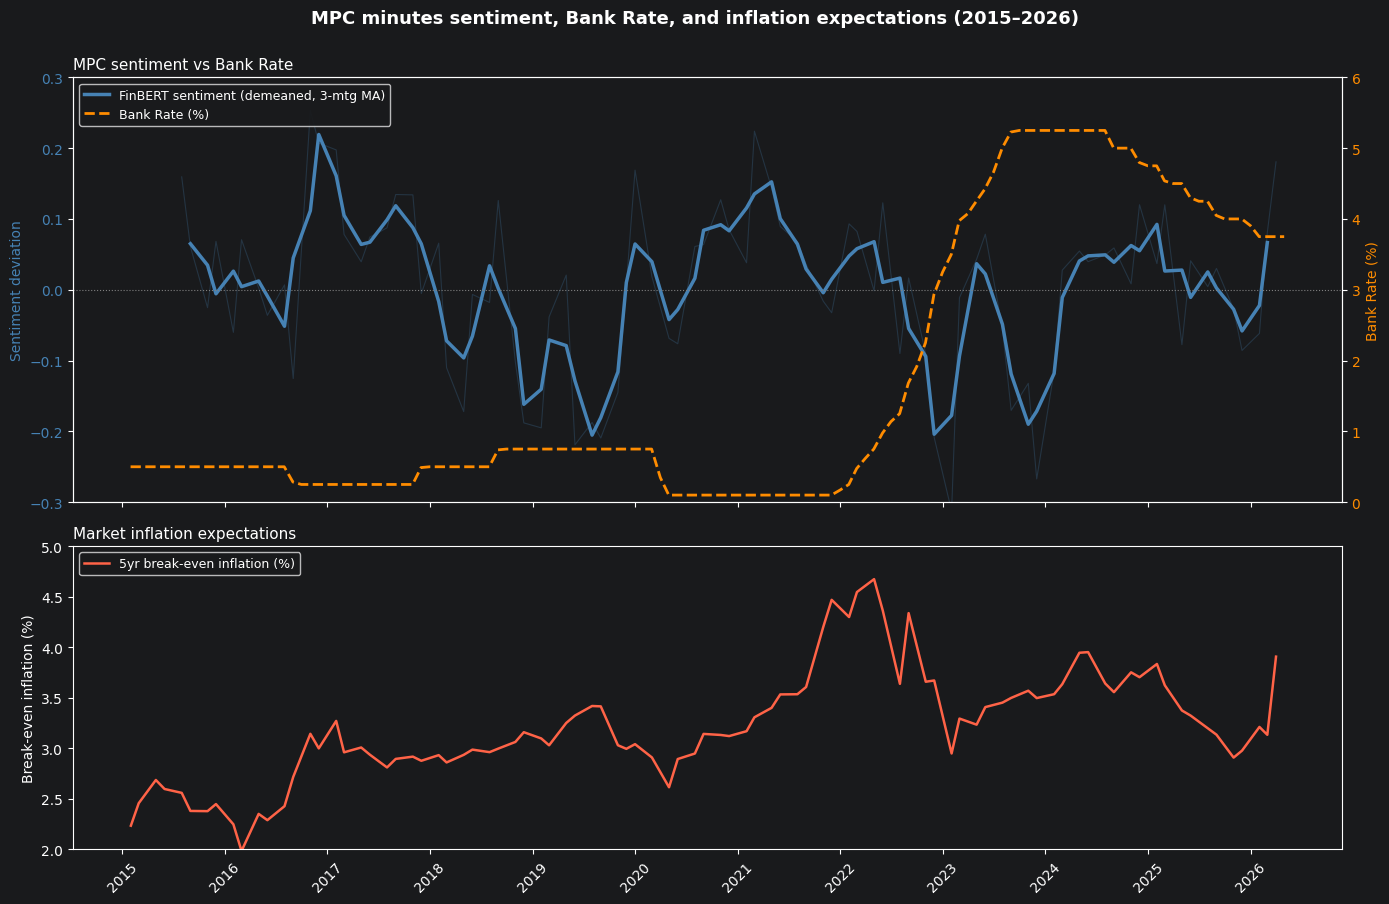

In [59]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 9), sharex=True,
                                gridspec_kw={"height_ratios": [1.4, 1]})


# Sentiment — left axis
ax1.plot(scores_df["date"], scores_df["finbert_demeaned"],
         color="steelblue", alpha=0.25, linewidth=0.8)
ax1.plot(scores_df["date"], scores_df["finbert_demeaned_smooth"],
         color="steelblue", linewidth=2.5,
         label="FinBERT sentiment (demeaned, 3-mtg MA)")
ax1.axhline(0, color="grey", linewidth=0.8, linestyle=":")
ax1.set_ylabel("Sentiment deviation", color="steelblue")
ax1.tick_params(axis="y", labelcolor="steelblue")
ax1.set_ylim(-0.3, 0.3)

# Bank Rate — right axis (twin)
ax1b = ax1.twinx()
ax1b.plot(bank_rate["date"], bank_rate["bank_rate"],
          color="darkorange", linewidth=2, linestyle="--",
          label="Bank Rate (%)")
ax1b.set_ylabel("Bank Rate (%)", color="darkorange")
ax1b.tick_params(axis="y", labelcolor="darkorange")
ax1b.set_ylim(0, 6)

# Combined legend for top panel
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax1b.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2,
           loc="upper left", fontsize=9, framealpha=0.9)
ax1.set_title("MPC sentiment vs Bank Rate", fontsize=11, loc="left")

ax2.plot(scores_df["date"], scores_df["breakeven_5yr"],
         color="tomato", linewidth=1.8,
         label="5yr break-even inflation (%)")
ax2.set_ylabel("Break-even inflation (%)")
ax2.set_ylim(2, 5)
ax2.legend(loc="upper left", fontsize=9, framealpha=0.9)
ax2.set_title("Market inflation expectations", fontsize=11, loc="left")

# X-axis formatting (shared)
ax2.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
ax2.xaxis.set_major_locator(mdates.YearLocator())
plt.setp(ax2.xaxis.get_majorticklabels(), rotation=45)

fig.suptitle("MPC minutes sentiment, Bank Rate, and inflation expectations (2015–2026)",
             fontsize=13, fontweight="bold", y=1.00)
plt.tight_layout()
plt.show()